<a href="https://www.kaggle.com/code/emmi1101/classifying-flora-floranativachilena-esp?scriptVersionId=336530879" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Introducción

El siguiente ejercicio aborda la clasificación de imágenes a partir de características cromáticas, incluyendo una capa de segmentación. El objetivo es generar una comprensión general de la manipulación de imágenes para su clasificación, mediante algoritmos de clasificación como SVC de la librería sklearn y otros auxiliares.

La pregunta que se pretende responder al final del ejercicio es: **¿Pueden clasificarse 10 especies de flora nativa con el algoritmo SVC?**  Para responder la pregunta, se evaluarán las métricas: **accuracy, precision, f1, recall**, así como una **matriz de confusión** para revisar los resultados para cada especie.


## Acerca del dataset:
Flora Nativa es un
El dataset para entrenamiento corresponde a un grupo de 1000 imágenes en formato **jpeg**, dividido en 10 especies, con 100 registros curados por el autor del dataset.


*   Autora: **Carola Andrea Figueroa Flores**
*   Tamaño: **(44.01 MB)**
*   Extensión de archivos: **jpg**

Especies listadas:    Maqui, Copihue, Ananuca, Chilco, Notro, Lingue, Azulillo, Chagual, Canelo, Quila










# Desarrollo

## Importar librerías

En primer lugar, cargo las librerías necesarias para el desarrollo del ejercicio.
1. Para la conexión con **kaggle**, importamos **os** para montar un directorio.
2. Para procesar las imagenes a trabajar, utilizo **glob**.
3. Para manipular las imágenes, trabajo con **matplotlib** y openCV **cv2**. la librería **seaborn** es usada en visualización.
4. Librerías de utilidad para kaggle y para evitar devolver las líneas de lectura del dataset de kaggle.
5. Ciencias de datos. **OneHotEncoder** utilizado para codificar, **train_test_split** para preprocesamiento de machine learning. **SVC** como clasificador. **GridSearchCV** para hiperparámetros de SVC. Finalmente, distintos módulos de **metrics** para medir rendimiento.

In [1]:
# Numeric and object manipulation

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

import glob

import cv2
#import matplotlib.pyplot as plt
import matplotlib.pylab as plt
import seaborn as sns

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
from IPython.display import clear_output

## From sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix





file = kagglehub.dataset_download('carolafigueroaflores/floranativachilena')
clear_output()

In [2]:
folder = file+'/test'

### Imagen como arreglo de 3 dimensiones. Sistema de color RGB

Para efectos de análisis de imágenes como datos, nos apoyaremos en dos conceptos claves.
Los objetos de tipo **array** en python nos permiten almacenar valores de n-dimensiones, las cuales luego pueden ser vectorizadas para el trabajo con datos.

Por otra parte, el sistema de colores RGB puede ser comprendido como un sistema de color aditivo. Por sus siglas Red, Green y Blue, postula un modo eficiente de formar el espectro de color mediante la combinación de sus tres elementos primarios, donde la adición de sus dimensiones en cada pixel genera el blanco y la ausencia el negro.

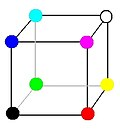




Por <a href="//commons.wikimedia.org/wiki/User:KES47" class="mw-redirect" title="User:KES47">KES47</a> - <a href="//commons.wikimedia.org/wiki/File:Avl3119color4a.jpg" title="File:Avl3119color4a.jpg">Avl3119color4a.jpg</a>, Dominio público, <a href="https://commons.wikimedia.org/w/index.php?curid=10548215">Enlace</a>

Para efectos de nuestro ejercicio, utilizo un registro aleatorio de Añañuca para construir la imagen como un objeto graficable. Utilizamos glob.

In [3]:

ananuka =folder+'/Ananuca/*.jpg'
ananuka = glob.glob(ananuka)



Con la función de lectura de imagen **imread**, creo un array con tres dimensiones (alto, largo, rgb) donde la imagen se compone de un plano bidimensaional (alto, largo), que a su vez contiene tres canales (RGB)

In [4]:
#plt.style.use('ggplot')
n = np.random.randint(1,len(ananuka))
img_ananuka = plt.imread(ananuka[n])
#cv_ananuka = cv2.imread(ananuka[n])
#cv_ananuka_rgb = cv2.cvtColor(cv_ananuka,cv2.COLOR_BGR2RGB)
img_ananuka.shape#, cv_ananuka.shape


(573, 550, 3)

Con el comando **imshow** graficamos la imagen inicial.

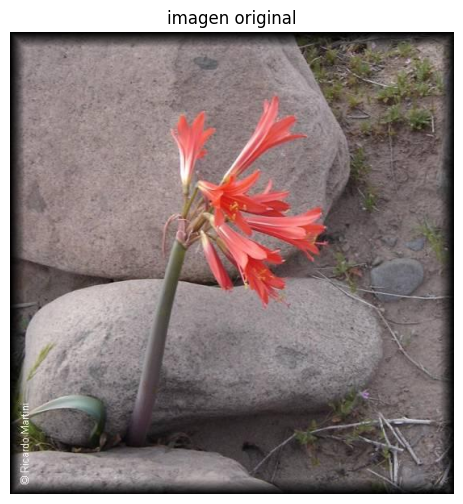

In [5]:
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img_ananuka)
ax.axis('off')
ax.set_title('imagen original')
plt.show()

Los tres canales pueden dividirse de la siguiente manera:

In [6]:
img_red= img_ananuka[:,:,0]
img_green= img_ananuka[:,:,1]
img_blue= img_ananuka[:,:,2]

Dividir los canales, nos permite hacer una representación de cada uno de ellos según un *cmap* de **imshow** asociado. Cada "gráfico" representa la intensidad de color de cada canal.
Para el ejemplo de la Añañuka, es esperable que el sector de floración contenga alta intensidad en el canal R, mientras que lo opuesto debería figurar en el canal B.

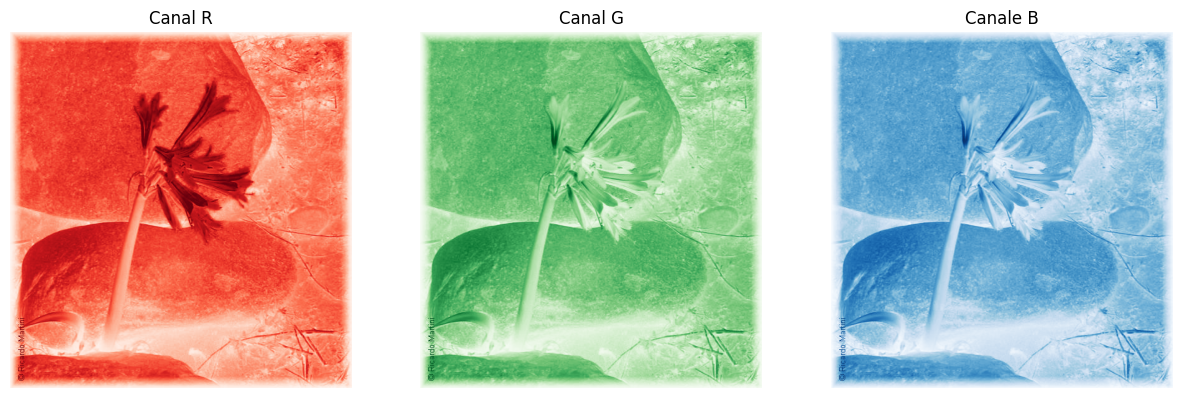

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(img_red, cmap='Reds')
axs[1].imshow(img_green, cmap='Greens')
axs[2].imshow(img_blue, cmap='Blues')
axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')
axs[0].set_title('Canal R')
axs[1].set_title('Canal G')
axs[2].set_title('Canale B')
plt.show()

Pero no solo podemos analizar una imagen en su dimensión original. La función *flatten* nos permite aplanar un arreglo, convirtiéndolo en una larga cadena unidimensional.

In [8]:
img_flatten = img_ananuka.flatten()

El gráfico a continuación, nos muestra un histograma de 16 bins de la misma imagen, para la cual se han agregado los pixeles en 64 bins. Esto nos permite tener un perfil general de la distribución de los pixeles en la imagen original

In [9]:
bins=16

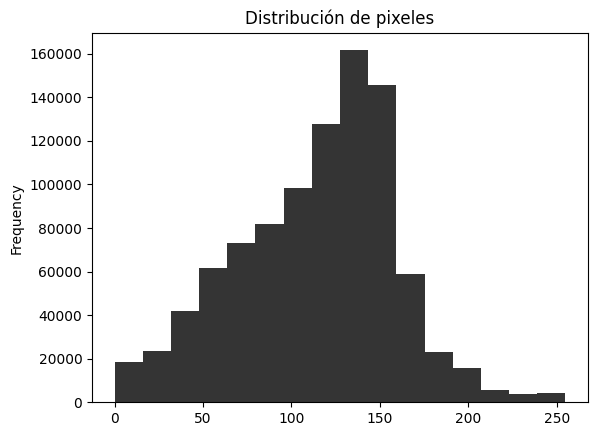

In [10]:

pd.Series(img_flatten).plot( kind = 'hist',bins=bins, title = 'Distribución de pixeles',color='#343434')
plt.show()

Al igual que la representación visual de los canales, podemos dividir los canales en un mismo histogram. (Nótese que en el caso de la representación, matplotlib tiene un sistema sustractivo sobre el parámetro *alpha*, distinto al caso de una pantalla al combinar fotones aditivamente)

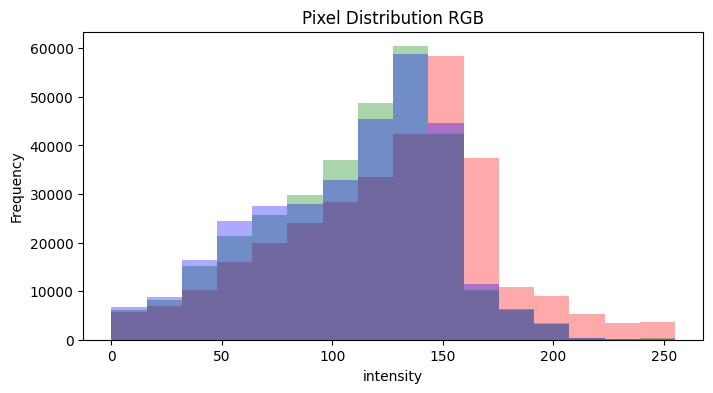

In [11]:
fig, ax = plt.subplots(figsize=(8,4))

pd.Series(img_ananuka[:,:,0].flatten()).plot( kind = 'hist',bins=bins, title = 'Pixel Distribution RGB',alpha=1/3,color='red')
pd.Series(img_ananuka[:,:,1].flatten()).plot( kind = 'hist',bins=bins, alpha=1/3,color='green')
pd.Series(img_ananuka[:,:,2].flatten()).plot( kind = 'hist',bins=bins, alpha=1/3,color='blue')
ax.set_xlabel('intensity')

plt.show()


In [12]:
data = []
for n in range(len(ananuka)):
    img_ananuka = plt.imread(ananuka[n])
    cv_ananuka_rgb = cv2.cvtColor(img_ananuka,cv2.COLOR_BGR2RGB)
    resized_image = cv2.resize(cv_ananuka_rgb,(512,512),interpolation=cv2.INTER_LINEAR)
    resized_image = resized_image / 255
    data.append(resized_image.flatten())

#data


## Preprocesamiento

Una vez que hemos comprendido el fundamento del manejo de una imagen como arreglo, es momento de procesar las imágenes para ser convertidas en arreglos manipulables por un algoritmo de clasificación.

Para esto, ejecutaremos un proceso **for** para las mil imágenes contenidas, en el que transformaremos la información de cada una, almacenando sus valores en listas que luego utilizaremos.

Antes de iniciar el *loop*, definimos las listas:
1. data: lista de imagen original.
2. data_r / data_g / data _b: lista con canales.
3. data_color_seg: lista con enmascaramiento de pixeles. Utilizado para segmentación experimental
4. cat: categoría. Corresponde a la especie y la variable a predecir.

Además, almacenamos las imágenes procesadas para hacer un análisis gráfico de su transformación.


Crearemos dos parámetros que utilizaremos luego para enmascaramiento

In [13]:
#LOWER_RGB = np.array([70, 0, 0])
#UPPER_RGB = np.array([255, 160, 255])

el ciclo for a continuación, recorre las carpetas, dentro de cada, genero otro ciclo for para transformar cada imagen.

En primer lugar, es necesario estandarizar el tamaño de las imagenes, así como reducir su dimensión. Para ello, usaremos OpenCV y su librería **cv** para la manipulación de imágenes.

Luego, una de las partes importantes para generar segmentación en la imagen, es crear enmascaramiento de pixeles.
estos parámetros, requieren la manipulación de la imagen al sistema de colores HSV (Hue, Saturation, Value) y sobre qué pixeles se aplica.
La combinación de estas capas de enmascaramiento permite generar un contorno más identificable y rellenar con negro, los espacios que no concuerdan con el enmascaramiento.

Finalmente, almacenamos el resultado de cada transformación para su posterior utilización. Cabe destacar que el modelo de entrenamiento necesitará aplanar las dimensiones, por lo cual la data a procesar es apendizada con función *flatten*.




In [14]:
dim=64
print(f' cantidad de pixeles por imagen: {dim**2 *3:,}')
#print(f' pixeles totales a crear: {dim**2 *3*10**3:,}')



 cantidad de pixeles por imagen: 12,288


In [15]:
data = []
data_r = []
data_g = []
data_b = []

data_color_seg = []
cat = []

rgb_img = []
rgb_seg_img = []
for item in os.listdir(folder):
    full_path = os.path.join(folder, item)
    if os.path.isdir(full_path):
        category = folder+'/'+item
        img = glob.glob(category+'/*.jpg')
        print(f"path: {category}")
        for n in range(len(img)):

            dimensions = (dim,dim)
            img_read = plt.imread(img[n])
            resized_image = cv2.resize(img_read,dimensions,interpolation=cv2.INTER_LINEAR)
            img_hsv = cv2.cvtColor(resized_image, cv2.COLOR_RGB2HSV)

            pythoncolor_ranges = { ## obtain with AI assistance
                # Red wraps around the HSV cylinder (both ends)
                "red_1": (np.array([0, 70, 50]), np.array([10, 255, 255])),
                "red_2": (np.array([170, 70, 50]), np.array([180, 255, 255])),

                # Added Orange & Pink for flower varieties
                "orange": (np.array([11, 70, 50]), np.array([25, 255, 255])),
                "pink": (np.array([160, 50, 50]), np.array([170, 255, 255])),

                "yellow": (np.array([20, 100, 100]), np.array([35, 255, 255])),
                "blue": (np.array([100, 50, 50]), np.array([130, 255, 255])),
                "purple": (np.array([130, 50, 50]), np.array([160, 255, 255])),
                "white": (np.array([0, 0, 180]), np.array([180, 40, 255]))

                # REMOVED "green" to filter out leaves and backgrounds automatically
            }

            combined_mask = np.zeros(img_hsv.shape[:2], dtype="uint8")

            for color, (lower, upper) in pythoncolor_ranges.items():
                lower_bound = np.array(lower, dtype="uint8")
                upper_bound = np.array(upper, dtype="uint8")

                mask = cv2.inRange(img_hsv, lower_bound, upper_bound)

                combined_mask = cv2.bitwise_or(combined_mask, mask)

            resized_image_norm = resized_image / 255.0

            rgb_segmented = np.where(combined_mask[:, :, np.newaxis] == 255, resized_image_norm, 0.0)

            data_r.append(resized_image_norm[:,:,0].flatten())
            data_g.append(resized_image_norm[:,:,1].flatten())
            data_b.append(resized_image_norm[:,:,2].flatten())
            data.append(resized_image_norm.flatten())
            data_color_seg.append(rgb_segmented.flatten())

            rgb_img.append(resized_image)
            rgb_seg_img.append(rgb_segmented)
            cat.append(item)

path: /kaggle/input/datasets/carolafigueroaflores/floranativachilena/test/Ananuca
path: /kaggle/input/datasets/carolafigueroaflores/floranativachilena/test/Chagual
path: /kaggle/input/datasets/carolafigueroaflores/floranativachilena/test/Chilco
path: /kaggle/input/datasets/carolafigueroaflores/floranativachilena/test/Lingue
path: /kaggle/input/datasets/carolafigueroaflores/floranativachilena/test/Quila
path: /kaggle/input/datasets/carolafigueroaflores/floranativachilena/test/Azulillo
path: /kaggle/input/datasets/carolafigueroaflores/floranativachilena/test/Maqui
path: /kaggle/input/datasets/carolafigueroaflores/floranativachilena/test/Notro
path: /kaggle/input/datasets/carolafigueroaflores/floranativachilena/test/Canelo
path: /kaggle/input/datasets/carolafigueroaflores/floranativachilena/test/Copihue


Valido una muestra

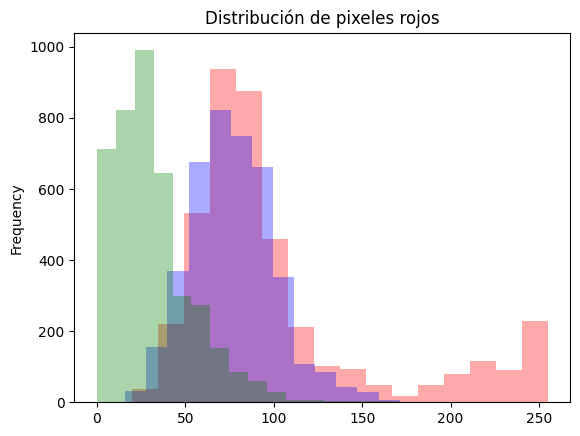

In [16]:
pd.Series(data_r[0]*255).plot( kind = 'hist',bins=16, title = 'Distribución de pixeles rojos',color='red',alpha=1/3)
pd.Series(data_g[0]*255).plot( kind = 'hist',bins=16, title = 'Distribución de pixeles rojos',color='blue',alpha=1/3)
pd.Series(data_b[0]*255).plot( kind = 'hist',bins=16, title = 'Distribución de pixeles rojos',color='green',alpha=1/3)


plt.show()

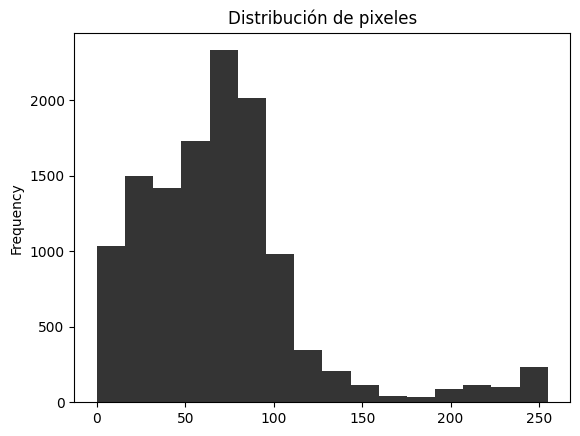

In [17]:
pd.Series(data[0]*255).plot( kind = 'hist',bins=16, title = 'Distribución de pixeles',color='#343434')
plt.show()

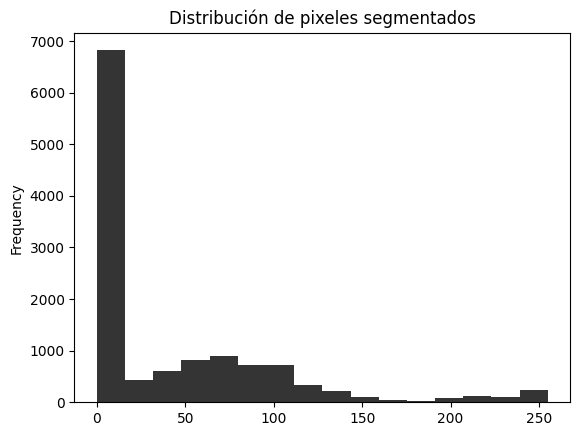

In [18]:
pd.Series(data_color_seg[0]*255).plot( kind = 'hist',bins=16, title = 'Distribución de pixeles segmentados',color='#343434')
plt.show()

Observamos un aumenrto significativo en la frecuencia 0 (negro). Al definir máscaras, se remueven pixeles de fondo, asociados a ambientes verdes para efecto de este ejercicio.

Para tener una idea de la cantidad de pixeles filtrados.

In [19]:

zero_count = np.sum(data_color_seg[0] == 0.0)
count = np.sum(data_color_seg[0] != 0.0)


print(f"Number of black/zero elements: {zero_count}")
print(f"Number of non black/zero elements: {count}")


Number of black/zero elements: 6514
Number of non black/zero elements: 5774


A continuación, una previsualización de imagen de cada especie con y sin enmascaramiento. Además del enmascaramiento, la reducción, baja de resolución y ajuste a marco cuadrado 64x64 se realiza para mantener un objeto reducido para entrenamiento.

In [20]:
rand = np.random.randint(1,99)

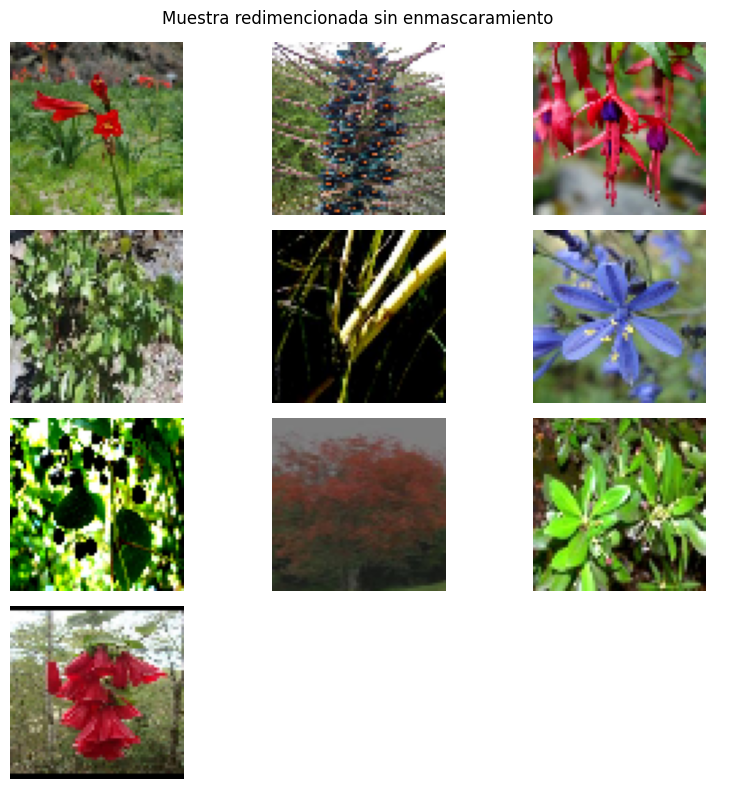

In [21]:
fig, axes = plt.subplots(4, 3, figsize=(8,8))
axes = axes.flatten()
for n in range(0,10):
    f = n*100+rand
    axes[n].imshow(rgb_img[f])
    axes[n].axis('off')
for j in range(len(range(0,10)),len(axes)):
  axes[j].axis('off')
fig.suptitle('Muestra redimencionada sin enmascaramiento')
plt.tight_layout()
plt.show()

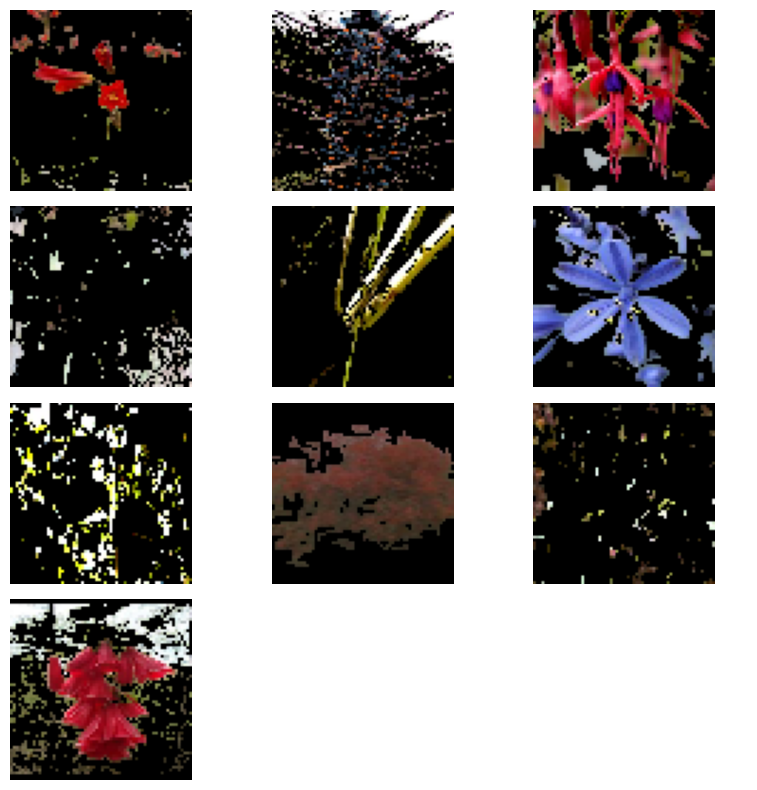

In [22]:
Imafig, axes = plt.subplots(4, 3, figsize=(8,8))
axes = axes.flatten()
for n in range(0,10):
    f = n*100+rand
    axes[n].imshow(rgb_seg_img[f])
    axes[n].axis('off')
for j in range(len(range(0,10)),len(axes)):
  axes[j].axis('off')
fig.suptitle('Muestra redimencionada sin enmascaramiento')
plt.tight_layout()
plt.show()


Conversión de listas a arreglos para preprocesamiento.

In [23]:
data = np.asarray(data_color_seg)
labels = np.asarray(cat)
labels_2d = labels.reshape(-1, 1)
print(f' data shape: {data.shape}')
print(f' labels shape: {labels.shape}')
print(f' labels_2d shape: {labels_2d.shape}')

 data shape: (1000, 12288)
 labels shape: (1000,)
 labels_2d shape: (1000, 1)


Con la librería OneHotEncoder convertimos y almacenamos valor categórico a valor numérico a predecir.

In [24]:

encoder = OneHotEncoder(sparse_output=False)
encoded_array = encoder.fit_transform(labels_2d)
labels_2d = np.argmax(encoded_array, axis=1) + 1


Con **train_test_split** separamos nuestros datos para entrenamiento, estratificando en *labels_2d* para mantener una proporción entre las categorías.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels_2d, test_size=0.25,shuffle=True,stratify=labels_2d
    )

#print(y_test)

validamos el tamaño de las variables para entrenamiento y prueba

In [26]:
print(f' shape of X train: {X_train.shape}')
print(f' shape of y train: {y_train.shape}')
print(f' shape of X test: {X_test.shape}')
print(f' shape of y test: {y_test.shape}')


 shape of X train: (750, 12288)
 shape of y train: (750,)
 shape of X test: (250, 12288)
 shape of y test: (250,)


Visualización de os datos de entrenamiento de prueba y entrenamiento de X, para confirmar que la ditribución no se encuentra sesgada.

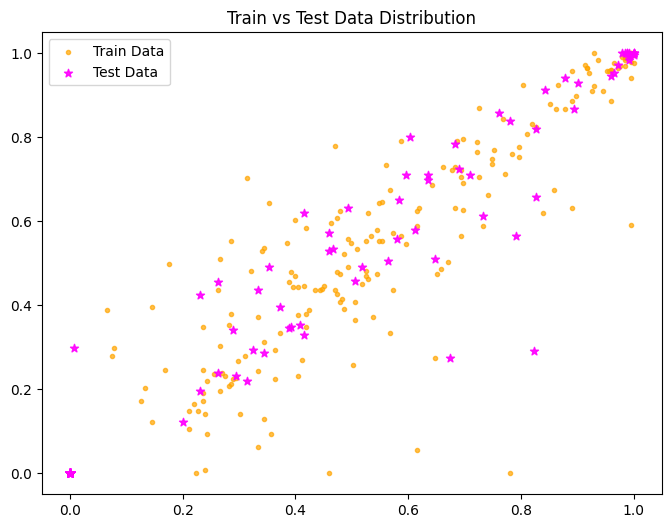

In [27]:
plt.figure(figsize=(8, 6))

# Plot training data
plt.scatter(X_train[:, 0], X_train[:, 1], c='orange', marker='.', label='Train Data', alpha=0.7)

# Plot testing data
plt.scatter(X_test[:, 0], X_test[:, 1], c='magenta', marker='*', label='Test Data', alpha=0.9)

plt.title('Train vs Test Data Distribution')
plt.legend()
plt.show()

## Clasificación

Una vez que tenemos nuestros conjuntos X e y para entrenamiento, podemos comenzar con la clasificación.

Para el caso de este ejercicio, se ha optado por el uso de SVC (Support Vector Clasifier)

In [28]:
classifier= SVC()

Se define una lista de parámetros para entrenamiento del modelo:
Las variables gamma y C han sido evaluada en sesiones previas, cargando

In [29]:
#parameters = [{'gamma':[0.01,0.001,0.0001],'C':[1,10,100,100]},{'kernel':['rbf']},{'class_weight':['balanced']},{'probability':[True]}]
parameters = [{'gamma':[0.001],'C':[100]},{'kernel':['rbf']},{'class_weight':['balanced']},{'probability':[True]}]

In [30]:
grid_search = GridSearchCV(classifier, parameters)

In [31]:
grid_search.fit(X_train,y_train)

GridSearchCV(estimator=SVC(),
             param_grid=[{'C': [100], 'gamma': [0.001]}, {'kernel': ['rbf']},
                         {'class_weight': ['balanced']},
                         {'probability': [True]}])

In [32]:
best_estimator = grid_search.best_estimator_
y_prediction = best_estimator.predict(X_test)


## Evaluación y métricas

In [33]:
accuracy = accuracy_score(y_test, y_prediction)
precision = precision_score(y_test, y_prediction,average='macro')
recall = recall_score(y_test, y_prediction,average='macro',zero_division=0)
f1 = f1_score(y_test, y_prediction,average='macro')

print(f'the accuracy score is: {accuracy}')
print(f'the precision score is: {precision}')
print(f'the recall score is: {round(recall,2)}')
print(f'the f1 score is: {round(f1,2)}')


the accuracy score is: 0.5
the precision score is: 0.4982423897941139
the recall score is: 0.5
the f1 score is: 0.49


In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_prediction,target_names=set(cat)))

              precision    recall  f1-score   support

     Chagual       0.50      0.52      0.51        25
       Quila       0.75      0.84      0.79        25
      Chilco       0.39      0.44      0.42        25
     Copihue       0.47      0.64      0.54        25
    Azulillo       0.58      0.60      0.59        25
      Lingue       0.53      0.72      0.61        25
       Maqui       0.47      0.28      0.35        25
       Notro       0.38      0.44      0.41        25
      Canelo       0.33      0.24      0.28        25
     Ananuca       0.58      0.28      0.38        25

    accuracy                           0.50       250
   macro avg       0.50      0.50      0.49       250
weighted avg       0.50      0.50      0.49       250



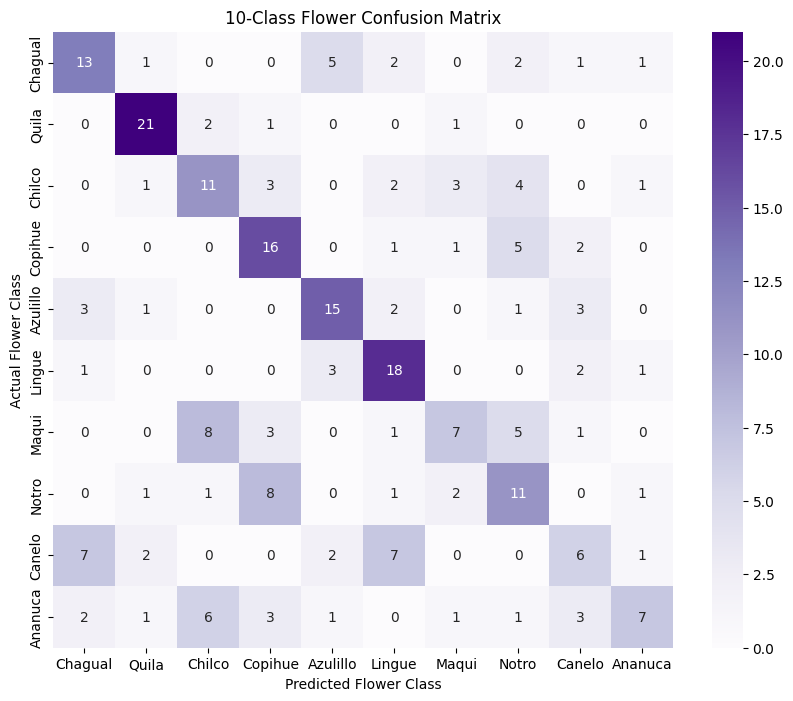

In [35]:

cm = confusion_matrix(y_test, y_prediction)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=set(cat), yticklabels=set(cat), cmap='Purples')
plt.ylabel('Actual Flower Class')
plt.xlabel('Predicted Flower Class')
plt.title('10-Class Flower Confusion Matrix')
plt.show()

## Conclusiones

El ejercicio


# Bibliografía y referencias

* [SVC sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)


https://www.geeksforgeeks.org/computer-vision/choosing-the-correct-upper-and-lower-hsv-boundaries-for-color-detection-with-cv-inrange-opencv/

https://handmap.github.io/hsv-vs-rgb/

https://www.youtube.com/watch?v=il8dMDlXrIE
https://www.youtube.com/watch?v=kSqxn6zGE0c&t=586s